In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
csv_file_path = 'RawData/Press_1027/2026-06-12_12-59-23_6Forces_40x10.csv'

In [3]:
try:
    df = pd.read_csv(csv_file_path)
    print("CSV file loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file at '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

CSV file loaded successfully!


In [4]:
df.shape

(48001, 219)

In [5]:
df.head()

,row_type,measurement_index,target_x_mm,target_y_mm,target_force_N,actual_x_mm,actual_y_mm,position_time_s,actual_force_N,force_time_s,...,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207,eit_time_s
0,baseline,NaN,NaN,NaN,NaN,NaN,NaN,0.267163,NaN,NaN,...,0.002562,0.001791,0.004264,0.004386,0.004999,0.005152,0.005979,0.000605,0.000869,0.267163
1,baseline,1.0,60.923077,22.772080,1.5,60.92,22.77,17.802742,0.0000,NaN,...,0.002479,0.001781,0.004307,0.004321,0.004789,0.005184,0.006035,0.000651,0.000845,18.003346
2,contact,1.0,60.923077,22.772080,1.5,60.92,22.77,17.802742,1.5463,25.026540,...,0.002606,0.001786,0.004551,0.004741,0.005212,0.005104,0.006022,0.000914,0.001287,26.225003
3,baseline,2.0,67.384615,24.521368,0.5,67.38,24.52,28.118621,0.0000,NaN,...,0.002444,0.001818,0.004443,0.004577,0.005094,0.005294,0.006054,0.000758,0.001010,28.172027
4,contact,2.0,67.384615,24.521368,0.5,67.38,24.52,28.118621,0.5346,32.071973,...,0.002512,0.001751,0.004405,0.004348,0.005070,0.004513,0.005197,0.000590,0.000871,33.149461


In [6]:

cols_to_exclude = ['target_force_N', 'actual_x_mm', 'actual_y_mm', 'position_time_s', 'force_time_s', 'eit_time_s']
df = df.drop(columns=cols_to_exclude, errors='ignore')

In [7]:
#Drop top row
df = df.drop(index=0).reset_index(drop=True)
df.head()

,row_type,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,...,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,baseline,1.0,60.923077,22.772080,0.0000,0.03831,0.02446,0.01520,0.01144,0.000707,...,0.001911,0.002479,0.001781,0.004307,0.004321,0.004789,0.005184,0.006035,0.000651,0.000845
1,contact,1.0,60.923077,22.772080,1.5463,0.03835,0.02453,0.01528,0.01148,0.000772,...,0.002188,0.002606,0.001786,0.004551,0.004741,0.005212,0.005104,0.006022,0.000914,0.001287
2,baseline,2.0,67.384615,24.521368,0.0000,0.03833,0.02467,0.01522,0.01141,0.000471,...,0.001964,0.002444,0.001818,0.004443,0.004577,0.005094,0.005294,0.006054,0.000758,0.001010
3,contact,2.0,67.384615,24.521368,0.5346,0.03819,0.02434,0.01503,0.01138,0.000612,...,0.001896,0.002512,0.001751,0.004405,0.004348,0.005070,0.004513,0.005197,0.000590,0.000871
4,baseline,3.0,65.769231,24.561254,0.0000,0.03825,0.02462,0.01525,0.01153,0.000640,...,0.002047,0.002556,0.001696,0.004294,0.004396,0.004993,0.005349,0.006218,0.000754,0.001044


In [8]:
# Subtract each baseline row from the following contact row, only for eit_* columns
eit_cols = df.columns[df.columns.str.startswith("eit_")].tolist()
if not eit_cols:
    raise ValueError("No columns starting with 'eit_' were found.")

if len(df) % 2 != 0:
    raise ValueError(f"Expected baseline/contact pairs, but df has an odd number of rows: {len(df)}")

row_types = df["row_type"].astype(str).str.strip().str.lower()
baseline_ok = row_types.iloc[0::2].eq("baseline").to_numpy()
contact_ok = row_types.iloc[1::2].isin(["contact"]).to_numpy()
print(f"Baseline rows OK: {baseline_ok.all()}, Contact rows OK: {contact_ok.all()}")
if not (baseline_ok.all() and contact_ok.all()):
    bad_pair = next(i for i, ok in enumerate(baseline_ok & contact_ok) if not ok)
    raise ValueError(
        "row_type must alternate baseline/contact (or baseline/contact). "
        f"First bad pair starts at row {2 * bad_pair}: "
        f"{row_types.iloc[2 * bad_pair]!r}, {row_types.iloc[2 * bad_pair + 1]!r}"
    )

baseline_idx = df.index[0::2]
measurement_idx = df.index[1::2]

df_subtracted = df.copy()
df_subtracted.loc[measurement_idx, eit_cols] = (
    df.loc[measurement_idx, eit_cols].to_numpy(dtype=float)
    - df.loc[baseline_idx, eit_cols].to_numpy(dtype=float)
)
# df_subtracted = df_subtracted.drop(index=baseline_idx).reset_index(drop=True)
df_subtracted = df_subtracted.drop(columns="row_type", errors='ignore')
df_subtracted.head()

Baseline rows OK: True, Contact rows OK: True


,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,...,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,1.0,60.923077,22.772080,0.0000,0.03831,0.02446,0.01520,0.01144,0.000707,0.004167,...,0.001911,0.002479,0.001781,0.004307,0.004321,0.004789,0.005184,0.006035,0.000651,0.000845
1,1.0,60.923077,22.772080,1.5463,0.00004,0.00007,0.00008,0.00004,0.000065,0.000233,...,0.000277,0.000127,0.000005,0.000244,0.000420,0.000423,-0.000080,-0.000013,0.000263,0.000442
2,2.0,67.384615,24.521368,0.0000,0.03833,0.02467,0.01522,0.01141,0.000471,0.004085,...,0.001964,0.002444,0.001818,0.004443,0.004577,0.005094,0.005294,0.006054,0.000758,0.001010
3,2.0,67.384615,24.521368,0.5346,-0.00014,-0.00033,-0.00019,-0.00003,0.000141,0.000076,...,-0.000068,0.000068,-0.000067,-0.000038,-0.000229,-0.000024,-0.000781,-0.000857,-0.000167,-0.000139
4,3.0,65.769231,24.561254,0.0000,0.03825,0.02462,0.01525,0.01153,0.000640,0.004137,...,0.002047,0.002556,0.001696,0.004294,0.004396,0.004993,0.005349,0.006218,0.000754,0.001044


In [9]:
df_shuffled = df_subtracted.sample(frac=1, random_state=22).reset_index(drop=True)
df_shuffled.head()

,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,...,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,23734.0,104.538462,17.199430,2.5473,-0.00287,-0.00303,-0.00193,-0.00243,-0.000820,-0.000379,...,0.000024,0.000834,-0.000116,-0.000308,-0.000374,-0.000361,-0.000424,-0.000244,-0.000509,-0.000333
1,6366.0,111.000000,11.000000,3.0659,-0.00402,-0.00266,-0.00166,-0.00148,-0.000075,-0.000029,...,-0.000207,0.000618,0.000052,-0.000044,-0.000098,-0.000233,-0.000249,-0.000224,-0.000364,-0.000134
2,19768.0,57.692308,15.102564,1.7904,0.00038,0.00000,0.00006,0.00010,0.000160,-0.000150,...,0.001143,0.000523,0.001015,0.000533,0.000737,0.000759,0.002753,0.003959,0.003144,0.002993
3,10248.0,59.307692,9.358974,0.0000,0.03772,0.02725,0.01801,0.01506,0.001938,0.004548,...,0.002790,0.000307,0.000906,0.004440,0.004328,0.004545,0.004376,0.005404,0.002154,0.002242
4,7831.0,107.769231,15.632479,2.1582,-0.00429,-0.00475,-0.00320,-0.00370,-0.001496,-0.000317,...,-0.000927,0.000758,-0.000747,-0.000018,-0.000134,0.000043,-0.000141,-0.000172,-0.000162,-0.000057


In [10]:
df_shuffled.describe()

,measurement_index,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,...,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,...,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
mean,12000.500000,79.500000,18.000000,1.710312,0.018888,0.012713,0.008037,0.006367,0.000602,0.001917,...,0.001172,0.000581,0.000499,0.001980,0.001840,0.002161,0.002062,0.002718,0.000905,0.000951
std,6928.275394,18.647219,5.120292,2.093475,0.019890,0.013805,0.009020,0.007528,0.000948,0.002077,...,0.001266,0.000706,0.000529,0.001986,0.001857,0.002162,0.002051,0.002606,0.001021,0.001044
min,1.000000,48.000000,9.000000,0.000000,-0.019100,-0.015550,-0.014806,-0.013921,-0.003092,-0.004531,...,-0.004078,-0.001860,-0.001553,-0.004547,-0.008523,-0.007712,-0.003657,-0.005085,-0.002258,-0.002316
25%,6000.750000,63.750000,13.562679,0.000000,-0.000440,-0.000510,-0.000450,-0.000530,-0.000053,-0.000044,...,0.000101,0.000078,0.000080,0.000092,0.000045,0.000034,-0.000051,0.000014,0.000087,0.000078
50%,12000.500000,79.500000,18.000000,0.250150,0.021765,0.015320,0.010720,0.008665,0.000617,0.003004,...,0.001476,0.000559,0.000598,0.002929,0.002679,0.003129,0.003201,0.004339,0.000930,0.001024
75%,18000.250000,95.250000,22.437322,3.190475,0.038290,0.026050,0.016590,0.013440,0.001269,0.003783,...,0.002078,0.001010,0.000761,0.003759,0.003532,0.004202,0.003852,0.005074,0.001584,0.001684
max,24000.000000,111.000000,27.000000,9.789600,0.046550,0.033710,0.022920,0.019800,0.006906,0.008692,...,0.005818,0.007791,0.007728,0.008512,0.013500,0.013040,0.014237,0.014649,0.013387,0.013240


In [11]:
from sklearn.model_selection import train_test_split
X = df_shuffled.loc[:, eit_cols].reset_index(drop=True)
Y= df_shuffled.loc[:].drop(columns=eit_cols).reset_index(drop=True)
print(Y, X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,
                                                    test_size=0.2,
                                                    random_state=0)

X_train.shape, X_test.shape

       measurement_index  target_x_mm  target_y_mm  actual_force_N
0                23734.0   104.538462    17.199430          2.5473
1                 6366.0   111.000000    11.000000          3.0659
2                19768.0    57.692308    15.102564          1.7904
3                10248.0    59.307692     9.358974          0.0000
4                 7831.0   107.769231    15.632479          2.1582
...                  ...          ...          ...             ...
47995            11516.0    62.538462    26.538462          0.0000
47996            12467.0   106.153846    20.384615          0.0000
47997            15841.0    88.384615    10.282051          0.0000
47998            14743.0    81.923077    10.076923          0.0000
47999            21947.0    93.230769    25.564103          6.3501

[48000 rows x 4 columns]          eit_0    eit_1    eit_2    eit_3     eit_4     eit_5     eit_6  \
0     -0.00287 -0.00303 -0.00193 -0.00243 -0.000820 -0.000379 -0.000443   
1     -0.00402 -0.00

((38400, 208), (9600, 208))

In [12]:
X_train.head()

,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,...,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
11727,0.03790,0.02496,0.01591,0.01267,0.000668,0.003741,0.004199,0.004793,0.005778,0.006982,...,0.001834,0.001013,0.000609,0.003322,0.002938,0.003476,0.003987,0.005087,0.001155,0.001291
9104,0.03793,0.02705,0.01736,0.01398,0.001502,0.003552,0.003816,0.004382,0.004899,0.005952,...,0.002582,0.000663,0.000706,0.003594,0.003317,0.004083,0.003611,0.004752,0.001509,0.001563
33114,0.03828,0.02540,0.01589,0.01256,0.000769,0.003428,0.003615,0.004379,0.004738,0.006362,...,0.001918,0.001178,0.000653,0.003027,0.003023,0.003790,0.002994,0.005280,0.001954,0.001965
44448,0.03710,0.02737,0.01796,0.01476,0.002211,0.004069,0.004410,0.004767,0.005932,0.006789,...,0.002947,0.000655,0.000768,0.003228,0.002661,0.003410,0.004104,0.005155,0.001419,0.001582
5679,0.03958,0.02716,0.01740,0.01373,0.000821,0.003892,0.004298,0.004938,0.005598,0.006631,...,0.001800,0.001583,0.000953,0.003950,0.003792,0.004290,0.004013,0.004985,0.001587,0.001718


In [13]:
Y_train.head()

,measurement_index,target_x_mm,target_y_mm,actual_force_N
11727,7171.0,94.846154,18.834758,0.0
9104,9149.0,91.615385,18.846154,0.0
33114,12913.0,90.000000,23.962963,0.0
44448,7980.0,67.384615,26.384615,0.0
5679,9991.0,90.000000,23.962963,0.0


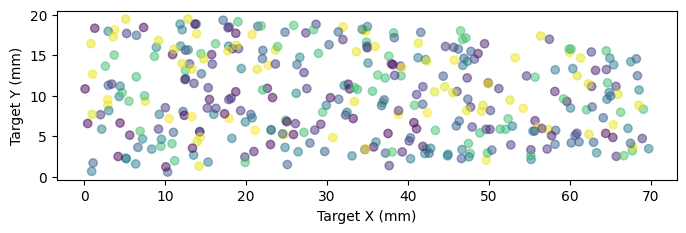

In [ ]:
#Plot an x,y scatter plot of the test points
plt.figure(figsize=(8, 6))
# plt.scatter(Y_test['target_x_mm'], Y_test['target_y_mm'], color='blue', label='Actual', alpha=0.5)
# plt.scatter(y_pred[:, 0], y_pred[:, 1], color='red', label='Predicted', alpha=0.5) 
#Make Aspect Ratio 1:1
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Target X (mm)')
plt.ylabel('Target Y (mm)')
#Set colour of each point based on the actual force value
scatter = plt.scatter(Y_test['target_x_mm'], Y_test['target_y_mm'], c=Y_test['actual_force_N'], cmap='viridis', label='Actual', alpha=0.5)
plt.show()

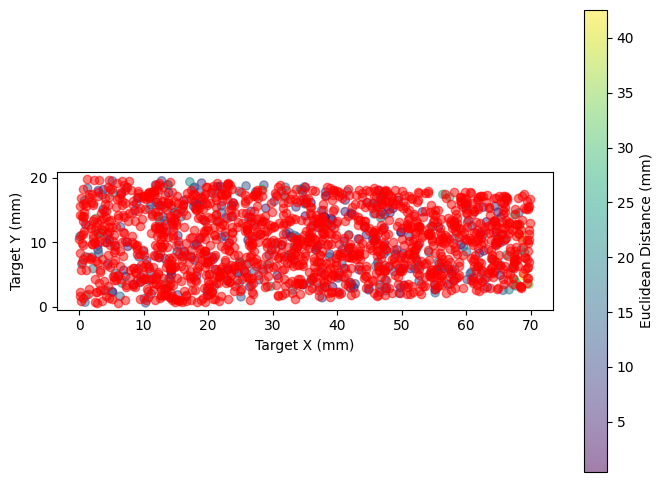

In [ ]:
#Plot the same scatter plot but with the colour being the euclidean distance between the predicted and actual points
from scipy.spatial import distance
euclidean_distances = distance.cdist(Y_test[['target_x_mm', 'target_y_mm']], y_pred[:, :2], metric='euclidean').diagonal()
plt.figure(figsize=(8, 6))
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Target X (mm)')
plt.ylabel('Target Y (mm)')
scatter = plt.scatter(Y_test['target_x_mm'], Y_test['target_y_mm'], c=euclidean_distances, cmap='viridis', label='Actual', alpha=0.5)
plt.scatter(Y_train['target_x_mm'], Y_train['target_y_mm'], color='red', label='Train', alpha=0.5)
plt.colorbar(scatter, label='Euclidean Distance (mm)')
plt.show()